# K-Means Clustering
Using the **Iris Dataset** to demonstrate K-Means Clustering step by step.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

Libraries imported successfully!


## 2. Load Dataset

In [2]:
# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add actual labels just for reference (NOT used in clustering)
df['actual_species'] = iris.target

print('Shape:', df.shape)
df.head()

Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('Dataset Info:')
print(df.info())
print('\nStatistical Summary:')
df.describe()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   actual_species     150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual_species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [4]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
actual_species       0
dtype: int64


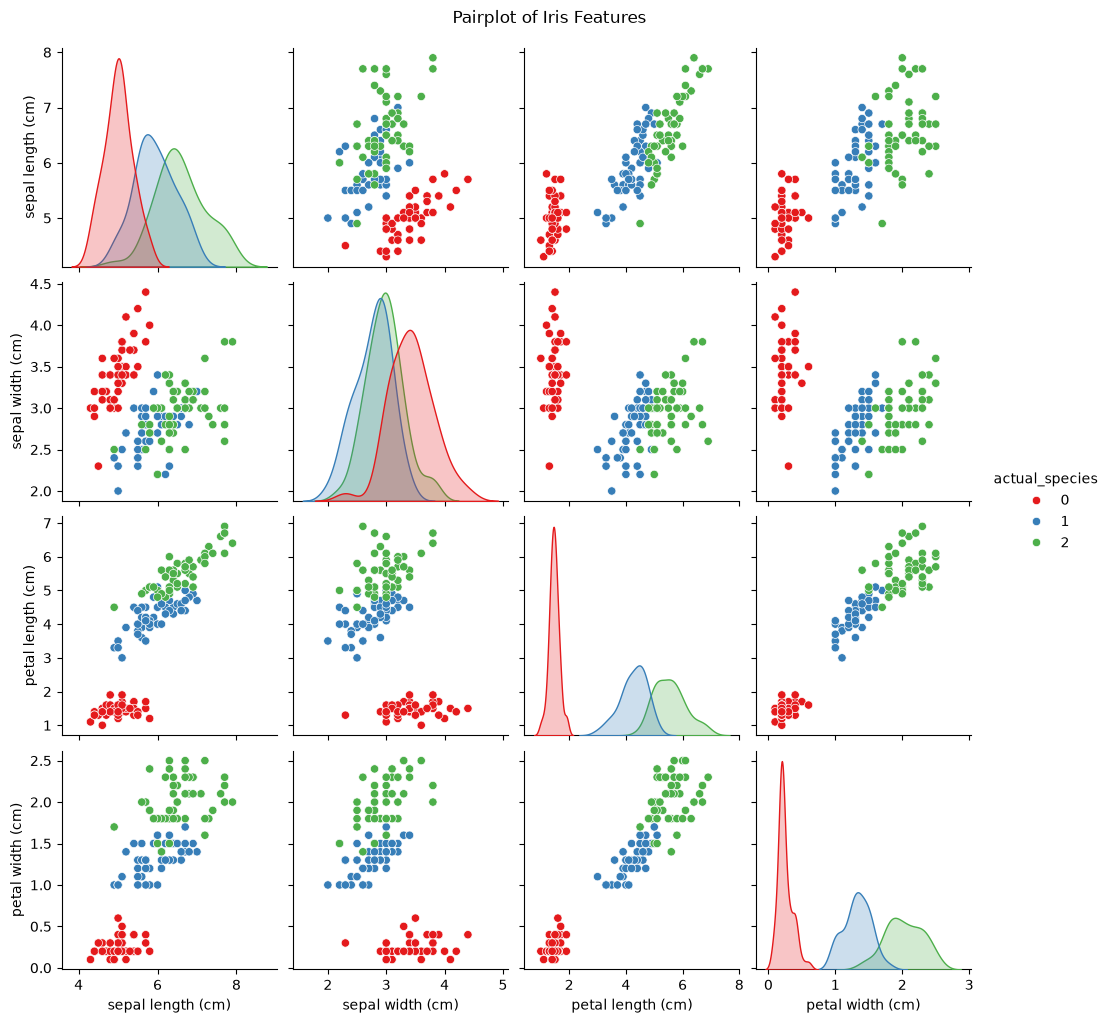

In [5]:
# Pairplot to visualize feature relationships
sns.pairplot(df, hue='actual_species', palette='Set1')
plt.suptitle('Pairplot of Iris Features', y=1.02)
plt.show()

## 4. Feature Scaling

In [6]:
# Use only feature columns (drop actual label)
X = df.drop('actual_species', axis=1)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Scaled Data Shape:', X_scaled.shape)

Scaled Data Shape: (150, 4)


## 5. Elbow Method — Find Optimal K

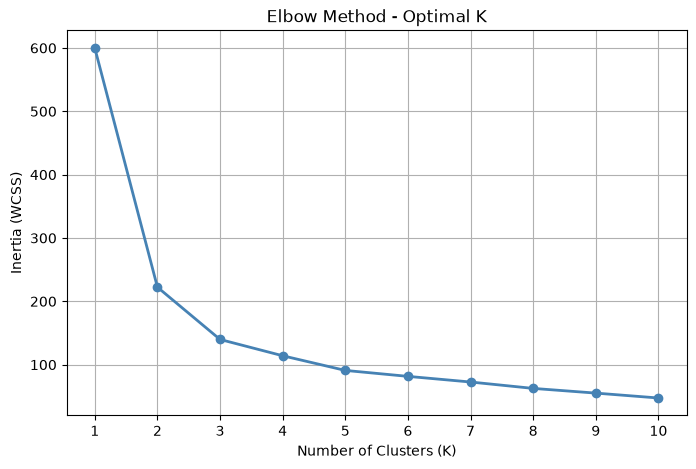

Inertia values: [599.9999999999999, 222.36170496502297, 139.8204963597497, 114.09254690403084, 90.92751382392046, 81.54439095511779, 72.63114382667185, 62.5406056957812, 55.11949280529059, 47.39103517634708]


In [7]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method - Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print('Inertia values:', inertia)

## 6. Silhouette Score — Confirm Best K

K=2  Silhouette Score: 0.5818
K=3  Silhouette Score: 0.4599
K=4  Silhouette Score: 0.3869
K=5  Silhouette Score: 0.3459
K=6  Silhouette Score: 0.3171
K=7  Silhouette Score: 0.3202
K=8  Silhouette Score: 0.3387
K=9  Silhouette Score: 0.3424
K=10  Silhouette Score: 0.3518


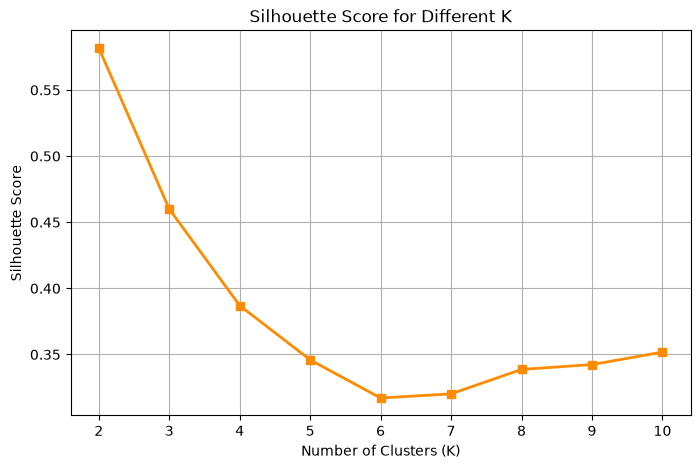

In [8]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'K={k}  Silhouette Score: {score:.4f}')

# Plot Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), sil_scores, marker='s', color='darkorange', linewidth=2)
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

## 7. Train Final K-Means Model (K=3)

In [9]:
# Train with K=3 (optimal from elbow + silhouette)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster Centers (scaled):')
print(kmeans.cluster_centers_)

print('\nCluster Distribution:')
print(df['cluster'].value_counts())

Cluster Centers (scaled):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]

Cluster Distribution:
cluster
0    53
1    50
2    47
Name: count, dtype: int64


## 8. Visualize Clusters using PCA (2D)

In [10]:
# Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

print(f'Explained Variance Ratio: {pca.explained_variance_ratio_}')
print(f'Total Variance Explained: {sum(pca.explained_variance_ratio_):.2%}')

Explained Variance Ratio: [0.72962445 0.22850762]
Total Variance Explained: 95.81%


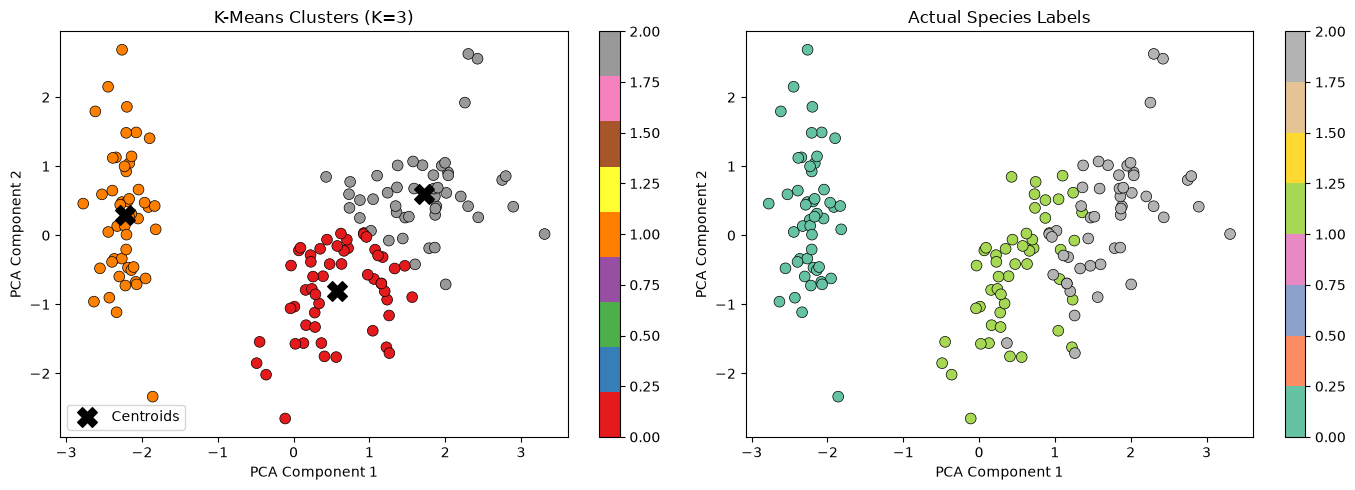

In [11]:
# Plot clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-Means Clusters
scatter1 = axes[0].scatter(df['PCA1'], df['PCA2'], c=df['cluster'], cmap='Set1', s=60, edgecolors='k', linewidths=0.5)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
                c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (K=3)')
axes[0].set_xlabel('PCA Component 1')
axes[0].set_ylabel('PCA Component 2')
axes[0].legend()
plt.colorbar(scatter1, ax=axes[0])

# Actual Labels for comparison
scatter2 = axes[1].scatter(df['PCA1'], df['PCA2'], c=df['actual_species'], cmap='Set2', s=60, edgecolors='k', linewidths=0.5)
axes[1].set_title('Actual Species Labels')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

## 9. Cluster Analysis

In [12]:
# Mean values of each feature per cluster
cluster_summary = df.groupby('cluster')[iris.feature_names].mean()
print('Cluster Feature Means:')
cluster_summary

Cluster Feature Means:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.428000,1.462000,0.246000
2,6.780851,3.095745,5.510638,1.972340


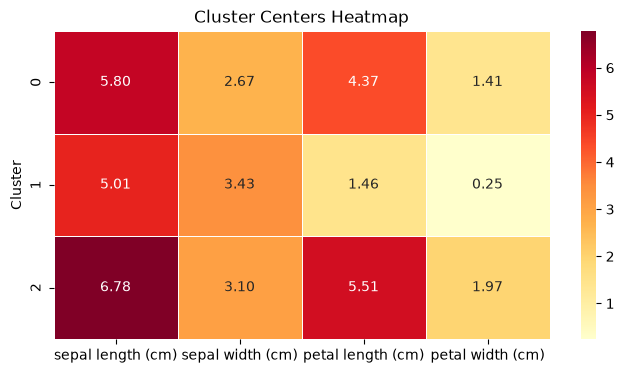

In [13]:
# Heatmap of cluster centers
plt.figure(figsize=(8, 4))
sns.heatmap(cluster_summary, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('Cluster Centers Heatmap')
plt.ylabel('Cluster')
plt.show()

## 10. Final Evaluation

In [14]:
final_silhouette = silhouette_score(X_scaled, df['cluster'])
final_inertia = kmeans.inertia_

print('='*40)
print('       K-MEANS FINAL RESULTS (K=3)')
print('='*40)
print(f'Inertia (WCSS)     : {final_inertia:.4f}')
print(f'Silhouette Score   : {final_silhouette:.4f}')
print(f'Clusters Found     : {kmeans.n_clusters}')
print('='*40)

       K-MEANS FINAL RESULTS (K=3)
Inertia (WCSS)     : 139.8205
Silhouette Score   : 0.4599
Clusters Found     : 3
